# Homework #1 — Complete Solutions

**ELEC70122: ML for Safety Critical Decision-Making**  
**Instructor: Sonali Parbhoo**  
**Total: 60 marks**

**Fall 2026**

In [2]:
### Import basic libraries
import numpy as np
import pandas as pd
import sklearn as sk
from scipy.stats import multivariate_normal, norm
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(42)

In [3]:
def get_posterior_samples(prior_var, noise_var, x_matrix, y_matrix, x_test_matrix, samples=100):
    '''Function to generate posterior predictive samples for Bayesian linear regression model'''
    prior_variance = np.diag(prior_var * np.ones(x_matrix.shape[1]))
    prior_precision = np.linalg.inv(prior_variance)

    joint_precision = prior_precision + x_matrix.T.dot(x_matrix) / noise_var
    joint_variance = np.linalg.inv(joint_precision)
    joint_mean = joint_variance.dot(x_matrix.T.dot(y_matrix)) / noise_var

    posterior_samples = np.random.multivariate_normal(joint_mean.flatten(), joint_variance, size=samples)
    posterior_predictions = np.dot(posterior_samples, x_test_matrix.T)
    posterior_predictive_samples = posterior_predictions[np.newaxis, :, :] + np.random.normal(0, noise_var**0.5, size=(100, posterior_predictions.shape[0], posterior_predictions.shape[1]))
    posterior_predictive_samples = posterior_predictive_samples.reshape((100 * posterior_predictions.shape[0], posterior_predictions.shape[1]))
    return posterior_predictions, posterior_predictive_samples


def generate_data(number_of_points=10, noise_variance=0.3):
    '''Function for generating toy regression data'''
    x_train = np.hstack((np.linspace(-1, -0.5, number_of_points), np.linspace(0.5, 1, number_of_points)))
    f = lambda x: 3 * x**3
    y_train = f(x_train) + np.random.normal(0, noise_variance**0.5, 2 * number_of_points)
    x_test = np.array(list(set(list(np.hstack((np.linspace(-1, 1, 200), x_train))))))
    x_test = np.sort(x_test)
    return x_train, y_train, x_test

---
## Part I: Maximum Likelihood Estimators for Polynomial Regression

### Problem 1 — Effect of Model Complexity (5 marks)

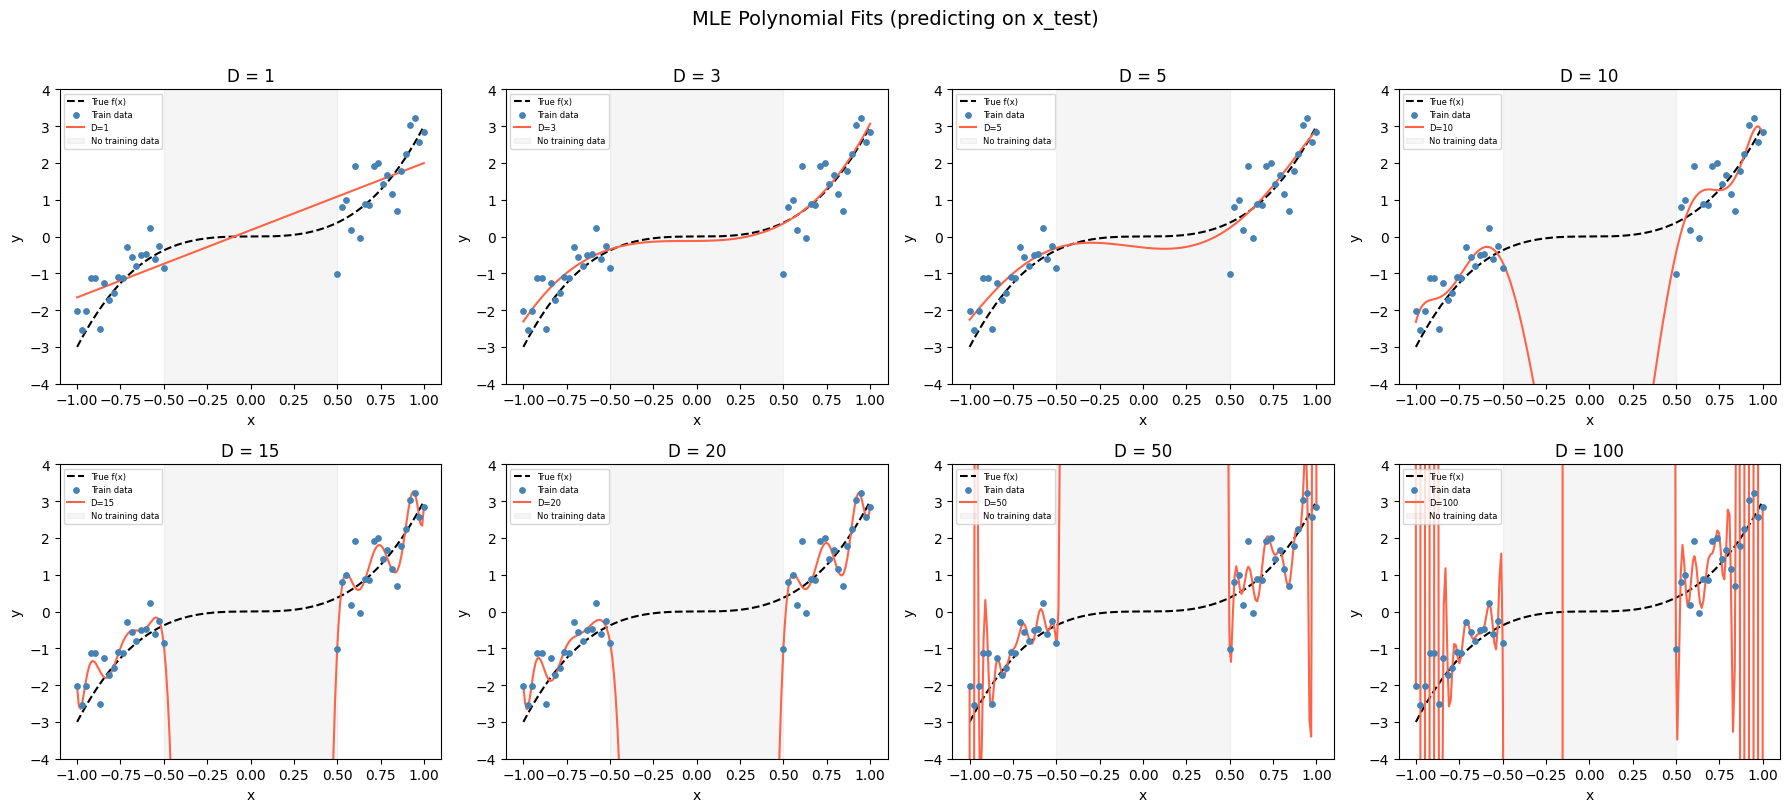

In [4]:
np.random.seed(0)
x_train, y_train, x_test = generate_data(number_of_points=20)

degrees = [1, 3, 5, 10, 15, 20, 50, 100]
f_true = lambda x: 3 * x**3

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, D in enumerate(degrees):
    poly = PolynomialFeatures(degree=D, include_bias=True)
    X_tr = poly.fit_transform(x_train.reshape(-1, 1))
    X_te = poly.transform(x_test.reshape(-1, 1))

    # MLE = OLS (may be ill-conditioned for high degrees — use lstsq)
    w, _, _, _ = np.linalg.lstsq(X_tr, y_train, rcond=None)
    y_pred = X_te @ w

    ax = axes[i]
    ax.plot(x_test, f_true(x_test), 'k--', label='True f(x)', linewidth=1.5)
    ax.scatter(x_train, y_train, s=15, color='steelblue', label='Train data', zorder=5)
    ax.plot(x_test, y_pred, color='tomato', linewidth=1.5, label=f'D={D}')
    ax.axvspan(-0.5, 0.5, alpha=0.08, color='grey', label='No training data')
    ax.set_ylim(-4, 4)
    ax.set_title(f'D = {D}')
    ax.legend(fontsize=6)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('MLE Polynomial Fits (predicting on x_test)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Discussion — Effect of Model Complexity**

- **D = 1 (underfitting):** A straight line cannot capture the cubic trend in the data; it has high bias everywhere.
- **D = 3 (good fit on training region):** Matches the true cubic fairly well in the training region and extrapolates reasonably because the polynomial basis matches the data-generating function.
- **D = 5 – 15 (modest overfit):** Fits the training points well but begins to exhibit oscillatory behaviour in the gap region [-0.5, 0.5] where there is no training data (the Runge phenomenon).
- **D ≥ 20 (severe overfit):** With enough parameters the model interpolates training points exactly, but predictions in the gap explode to extreme values. This is especially dangerous at deployment: the covariate-shifted test region [-0.5, 0.5] is precisely where the model is most unreliable, yet there is nothing in the training loss to signal this problem.

The core issue is that **MLE minimises training error only** — it has no way to penalise poor extrapolation into the gap.

### Problem 2 — Model Selection via Cross-Validation (Bootstrap) (5 marks)

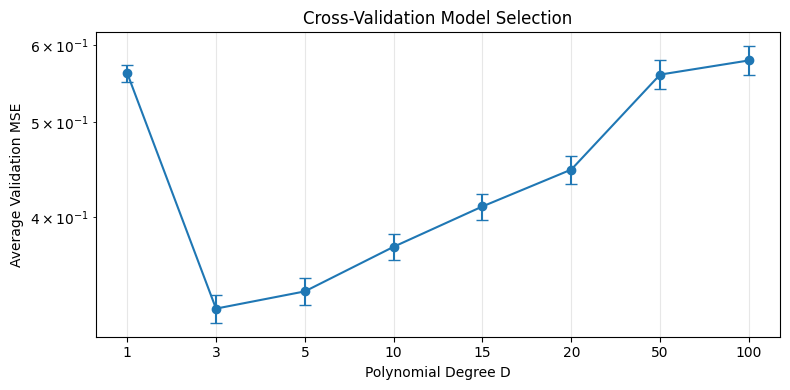

Optimal degree by CV: D = 3 (mean MSE = 0.3224)


In [5]:
np.random.seed(1)
S = 50  # bootstrap replicates
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
cv_mse = {D: [] for D in degrees}

for _ in range(S):
    # Each replicate: sample two independent datasets
    x_tr_s, y_tr_s, _ = generate_data(number_of_points=20)
    x_val_s, y_val_s, _ = generate_data(number_of_points=20)

    for D in degrees:
        poly = PolynomialFeatures(degree=D, include_bias=True)
        X_tr = poly.fit_transform(x_tr_s.reshape(-1, 1))
        X_val = poly.transform(x_val_s.reshape(-1, 1))
        w, _, _, _ = np.linalg.lstsq(X_tr, y_tr_s, rcond=None)
        mse = np.mean((x_val_s**0 * 0 + y_val_s - X_val @ w)**2)  # clean form below
        cv_mse[D].append(mse)

# Recompute cleanly
cv_mse = {D: [] for D in degrees}
for _ in range(S):
    x_tr_s, y_tr_s, _ = generate_data(number_of_points=20)
    x_val_s, y_val_s, _ = generate_data(number_of_points=20)
    for D in degrees:
        poly = PolynomialFeatures(degree=D, include_bias=True)
        X_tr = poly.fit_transform(x_tr_s.reshape(-1, 1))
        X_val = poly.transform(x_val_s.reshape(-1, 1))
        w, _, _, _ = np.linalg.lstsq(X_tr, y_tr_s, rcond=None)
        cv_mse[D].append(np.mean((y_val_s - X_val @ w)**2))

mean_mse = [np.mean(cv_mse[D]) for D in degrees]
std_mse  = [np.std(cv_mse[D]) / np.sqrt(S) for D in degrees]

plt.figure(figsize=(8, 4))
plt.errorbar(range(len(degrees)), mean_mse, yerr=std_mse, marker='o', capsize=4)
plt.xticks(range(len(degrees)), degrees)
plt.xlabel('Polynomial Degree D')
plt.ylabel('Average Validation MSE')
plt.title('Cross-Validation Model Selection')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_idx = np.argmin(mean_mse)
print(f'Optimal degree by CV: D = {degrees[optimal_idx]} (mean MSE = {mean_mse[optimal_idx]:.4f})')

**Discussion — Why Cross-Validation Mitigates Overfitting**

Cross-validation evaluates model performance on **held-out data** that was not used in fitting. A model that memorises training noise (high-degree polynomial) will generalise poorly and receive a high validation MSE, while a model that captures true structure will score well. This directly penalises the failure mode identified in Problem 1 — explosive extrapolation arises from models that overfit training noise, and those same models produce high validation error. By selecting the degree at the 'elbow' of the validation-MSE curve (where further complexity stops helping), we choose the simplest model that adequately captures the signal, consistent with Occam's Razor.

### Problem 3 — Uncertainty Estimation via Bootstrap Ensembles (5 marks)

**Ideal Uncertainty Profile**

The ideal uncertainty should be **low in the training-data rich regions** (x ∈ [-1, -0.5] ∪ [0.5, 1]) and **high in the gap region** (x ∈ [-0.5, 0.5]), where no training data exists. This is precisely the condition for safe deployment under covariate shift: if the model correctly signals high uncertainty in regions it has never seen, a human-in-the-loop system can defer to expert judgement rather than blindly trusting the model's output.

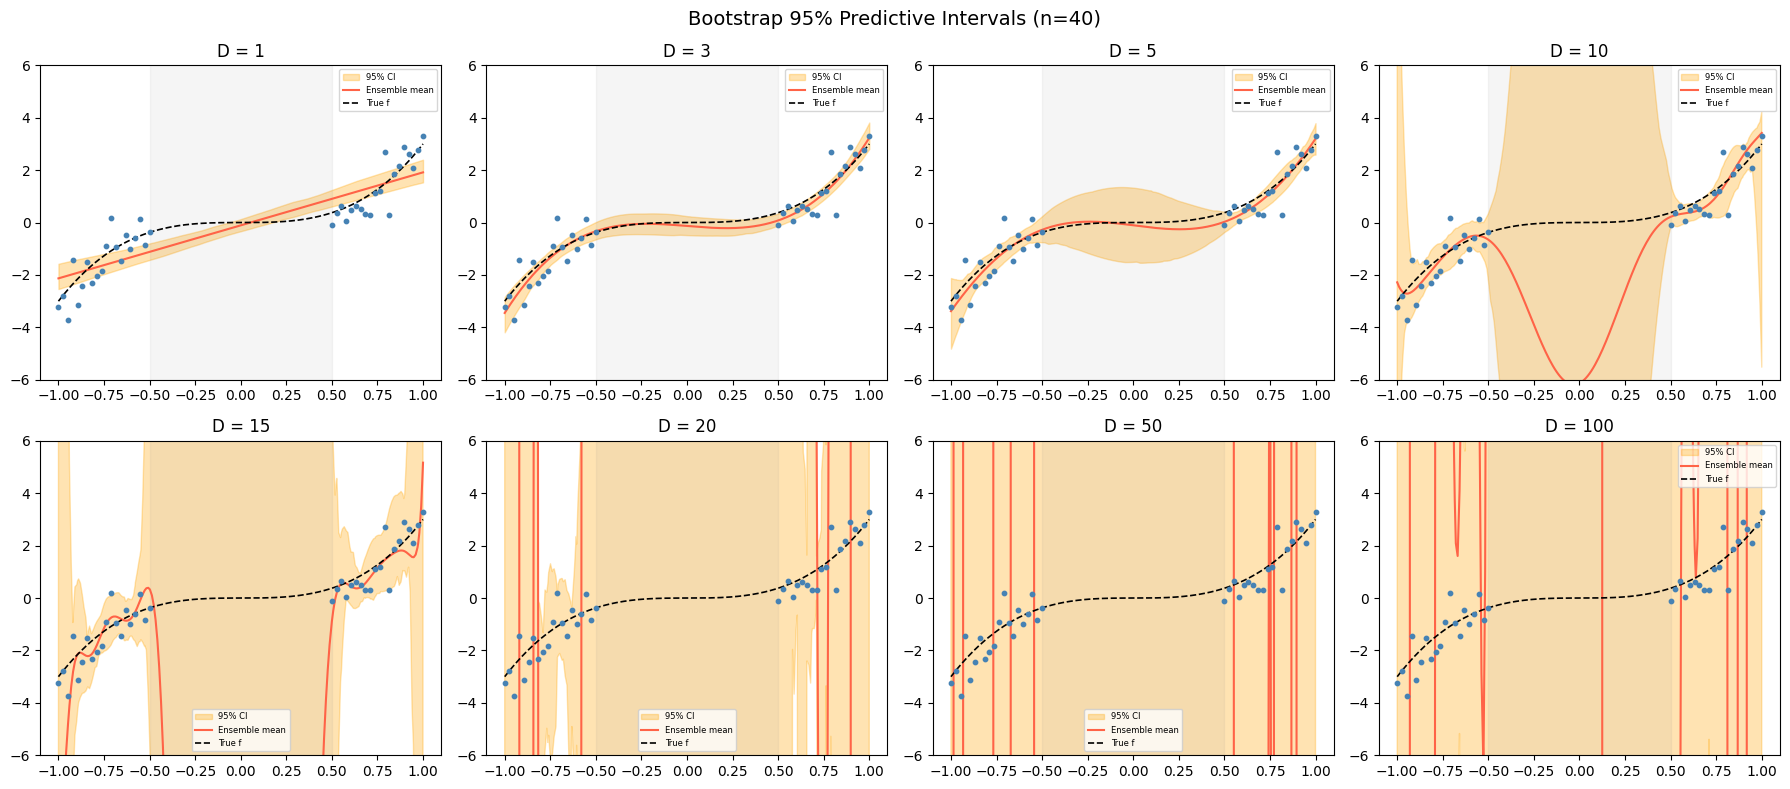

In [6]:
np.random.seed(2)
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
B = 200  # bootstrap models

x_train, y_train, x_test = generate_data(number_of_points=20)
n = len(x_train)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, D in enumerate(degrees):
    preds = []
    poly = PolynomialFeatures(degree=D, include_bias=True)
    X_te = poly.fit_transform(x_test.reshape(-1, 1))

    for _ in range(B):
        idx = np.random.choice(n, n, replace=True)
        X_b = poly.fit_transform(x_train[idx].reshape(-1, 1))
        w, _, _, _ = np.linalg.lstsq(X_b, y_train[idx], rcond=None)
        preds.append(X_te @ w)

    preds = np.array(preds)  # (B, len(x_test))
    mean_pred = preds.mean(0)
    lo = np.percentile(preds, 2.5, axis=0)
    hi = np.percentile(preds, 97.5, axis=0)

    ax = axes[i]
    ax.fill_between(x_test, lo, hi, alpha=0.3, color='orange', label='95% CI')
    ax.plot(x_test, mean_pred, color='tomato', lw=1.5, label='Ensemble mean')
    ax.plot(x_test, 3*x_test**3, 'k--', lw=1.2, label='True f')
    ax.scatter(x_train, y_train, s=10, zorder=5, color='steelblue')
    ax.axvspan(-0.5, 0.5, alpha=0.08, color='grey')
    ax.set_ylim(-6, 6)
    ax.set_title(f'D = {D}')
    ax.legend(fontsize=6)

plt.suptitle('Bootstrap 95% Predictive Intervals (n=40)', fontsize=14)
plt.tight_layout()
plt.show()

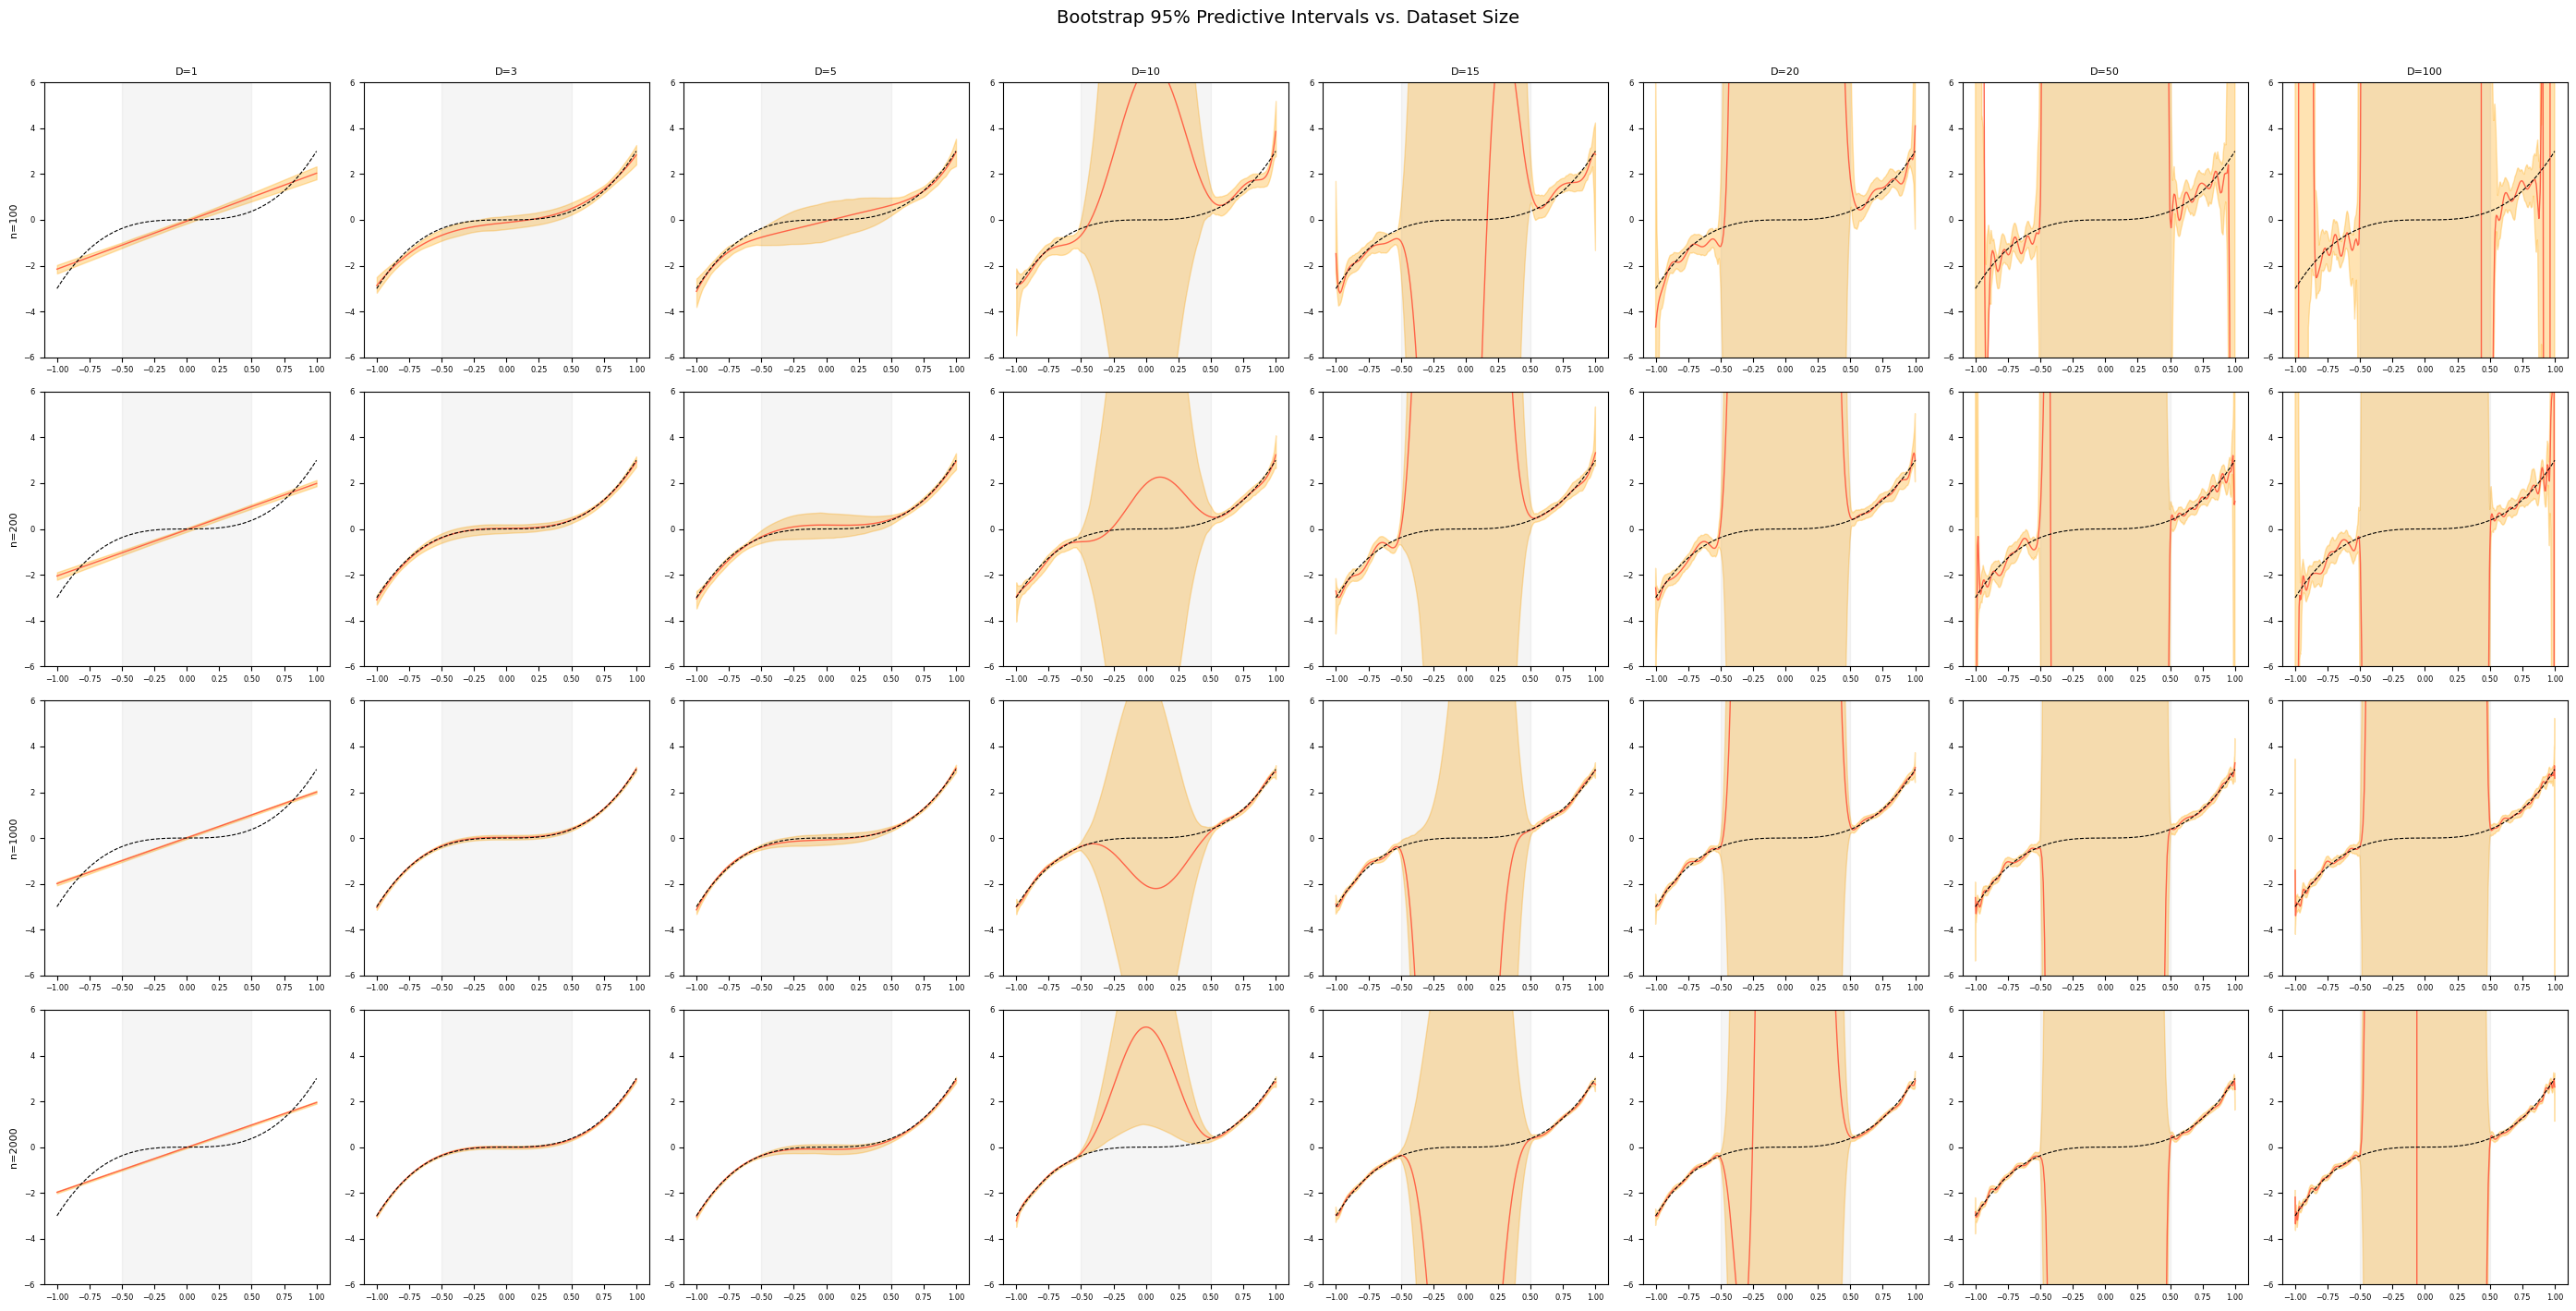

In [7]:
# Same plots for larger datasets
n_points_list = [50, 100, 500, 1000]
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
B = 100

fig, big_axes = plt.subplots(len(n_points_list), len(degrees), figsize=(28, 14))

for row, npts in enumerate(n_points_list):
    np.random.seed(3)
    x_tr, y_tr, x_te = generate_data(number_of_points=npts)
    n = len(x_tr)
    for col, D in enumerate(degrees):
        poly = PolynomialFeatures(degree=D, include_bias=True)
        X_te = poly.fit_transform(x_te.reshape(-1, 1))
        preds = []
        for _ in range(B):
            idx = np.random.choice(n, n, replace=True)
            X_b = poly.fit_transform(x_tr[idx].reshape(-1, 1))
            w, _, _, _ = np.linalg.lstsq(X_b, y_tr[idx], rcond=None)
            preds.append(X_te @ w)
        preds = np.array(preds)
        lo = np.percentile(preds, 2.5, axis=0)
        hi = np.percentile(preds, 97.5, axis=0)
        ax = big_axes[row, col]
        ax.fill_between(x_te, lo, hi, alpha=0.3, color='orange')
        ax.plot(x_te, preds.mean(0), color='tomato', lw=1)
        ax.plot(x_te, 3*x_te**3, 'k--', lw=0.8)
        ax.axvspan(-0.5, 0.5, alpha=0.08, color='grey')
        ax.set_ylim(-6, 6)
        if row == 0: ax.set_title(f'D={D}', fontsize=8)
        if col == 0: ax.set_ylabel(f'n={2*npts}', fontsize=8)
        ax.tick_params(labelsize=6)

plt.suptitle('Bootstrap 95% Predictive Intervals vs. Dataset Size', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Discussion — Ensemble Bootstrap Uncertainty**

- **In training-rich regions** (x ∈ [-1, -0.5] ∪ [0.5, 1]), as the training set size grows the bootstrap ensemble predictions converge: the interval narrows. This is expected — MLE is **consistent**, so with more data all bootstrap resamples agree on the same estimate.

- **In the gap region** (x ∈ [-0.5, 0.5]), high-degree models start with wide intervals (many bootstrap models disagree), but as n → 1000 the intervals collapse here too. With abundant data, each bootstrap resample produces nearly the same high-degree polynomial, so the ensemble variance vanishes. This is **not ideal**: the model remains highly uncertain about the truth in the gap, yet the interval no longer reflects this.

- This reveals a fundamental limitation of bootstrap uncertainty: it measures **sampling variability of the estimator**, not **epistemic uncertainty about the function**. When data is plentiful, sampling variability goes to zero even in unseen regions, masking genuine ignorance. Therefore, ensemble bootstrap uncertainty is **not suitable** for detecting covariate shift risk.

### Problem 4 — Effect of L2 Regularization on Bootstrap Uncertainty (3 marks)

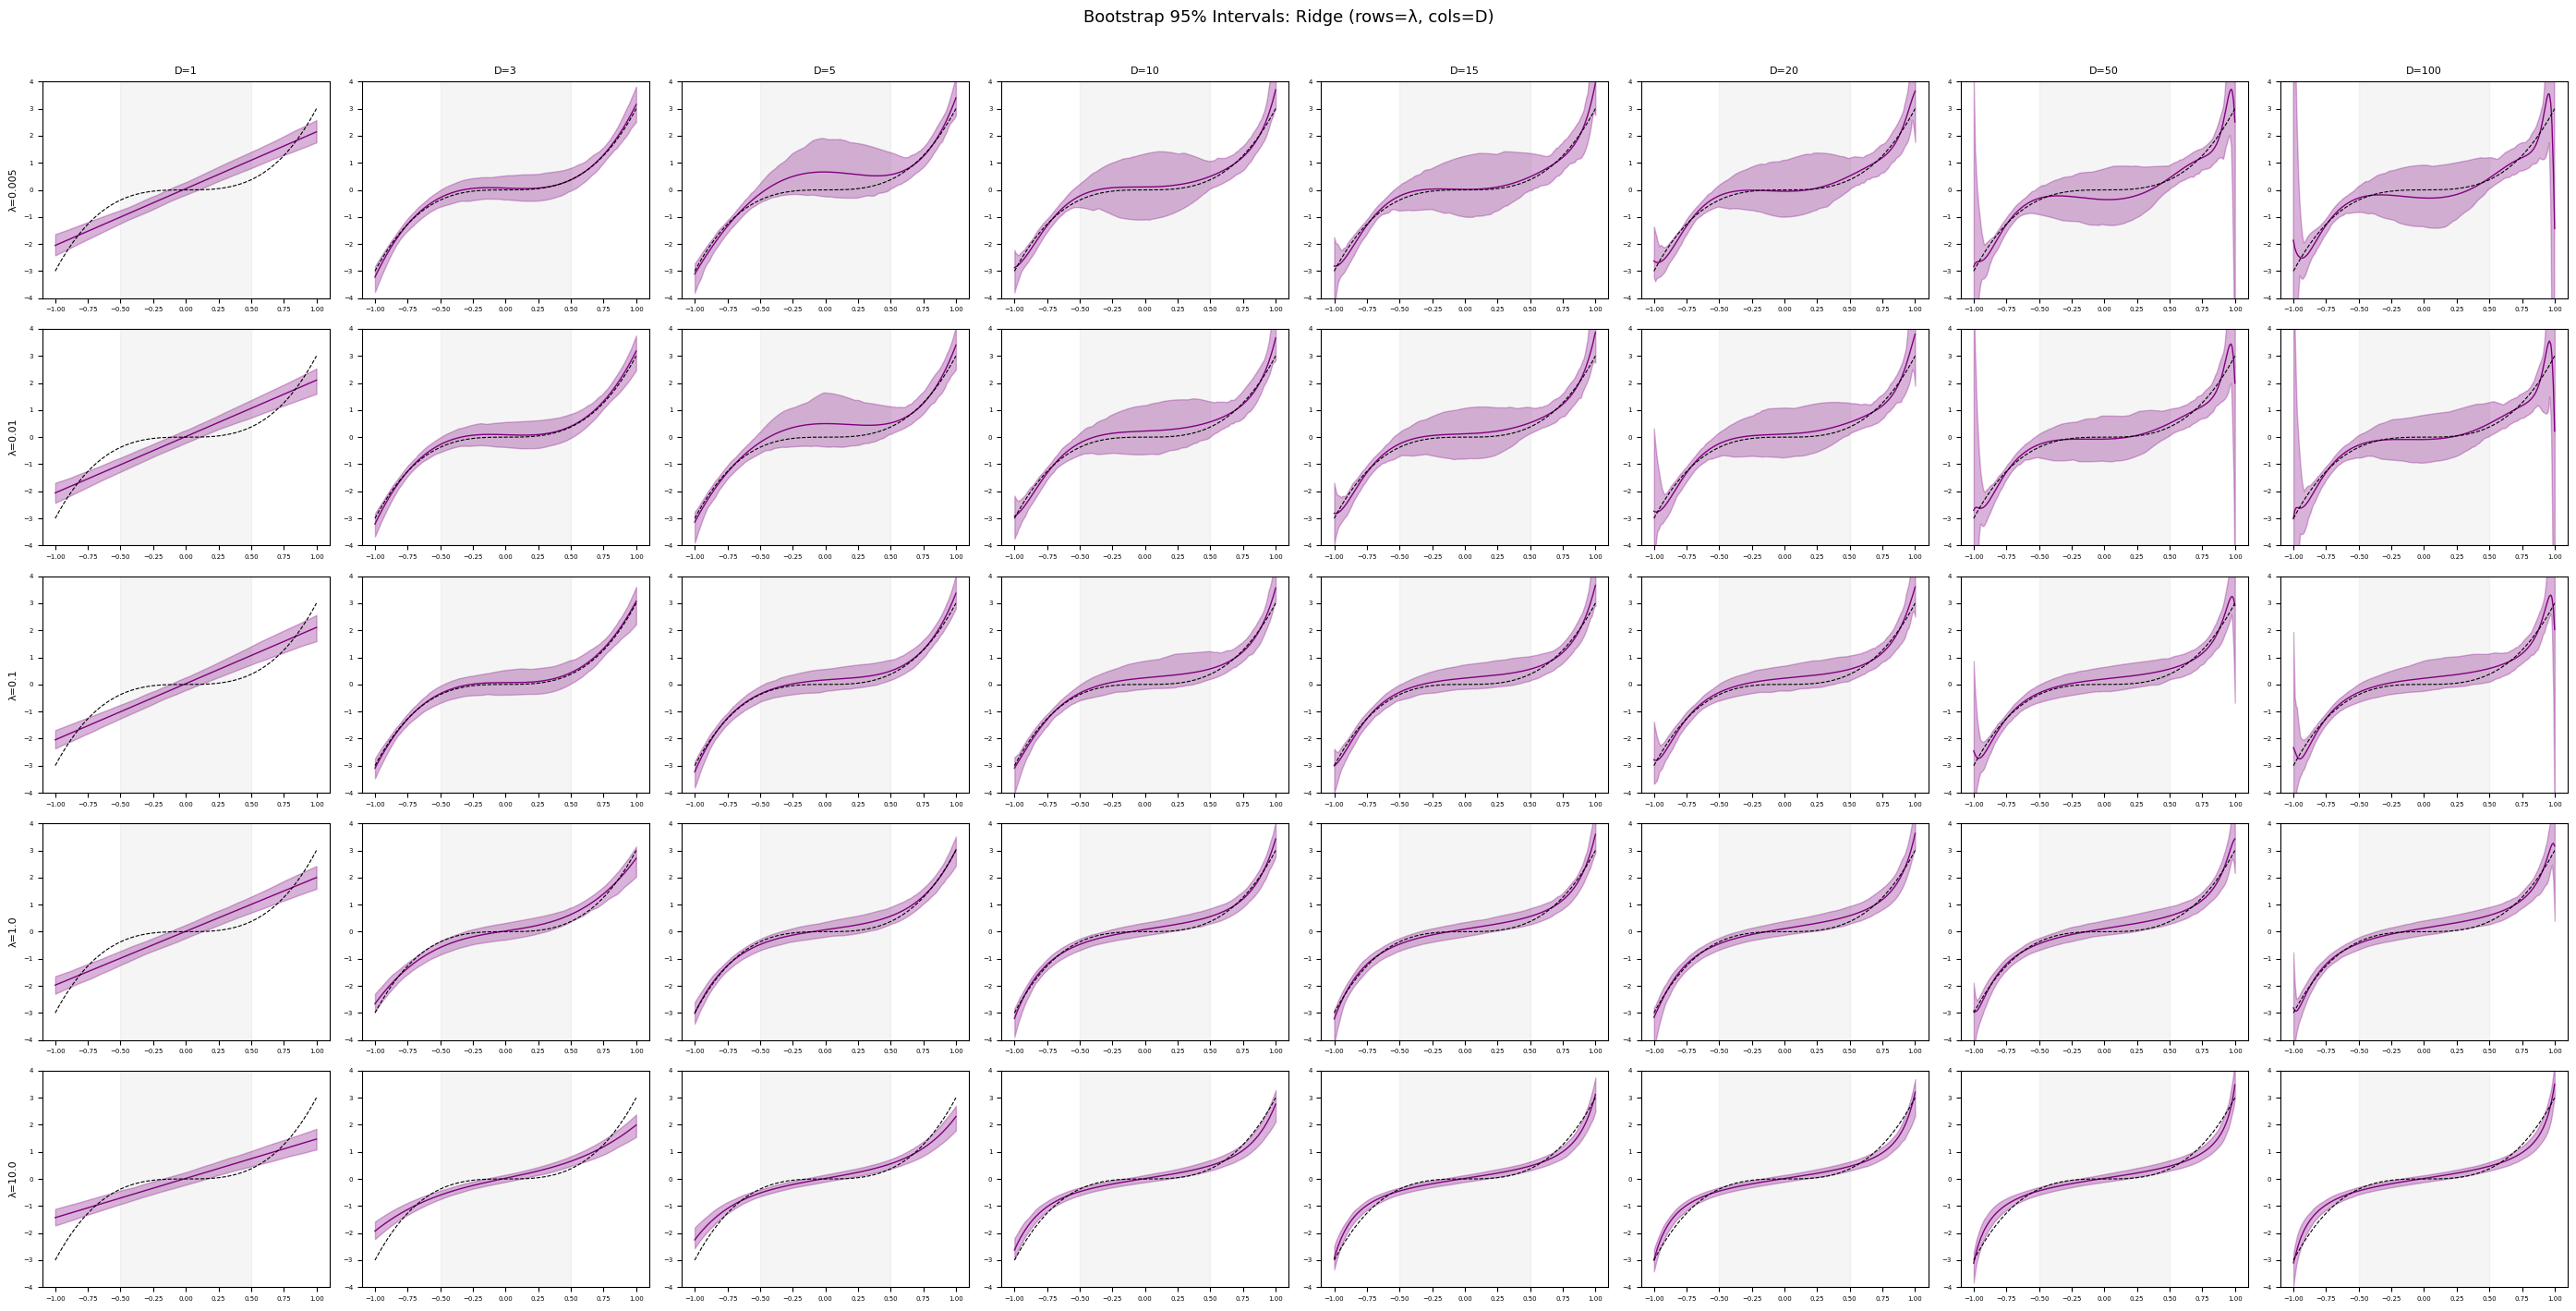

In [8]:
np.random.seed(4)
x_train, y_train, x_test = generate_data(number_of_points=20)
n = len(x_train)
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
alphas = [5e-3, 1e-2, 1e-1, 1e0, 1e1]
B = 200

fig, axes = plt.subplots(len(alphas), len(degrees), figsize=(28, 14))

for row, alpha in enumerate(alphas):
    for col, D in enumerate(degrees):
        poly = PolynomialFeatures(degree=D, include_bias=True)
        X_te = poly.fit_transform(x_test.reshape(-1, 1))
        preds = []
        for _ in range(B):
            idx = np.random.choice(n, n, replace=True)
            X_b = poly.fit_transform(x_train[idx].reshape(-1, 1))
            ridge = Ridge(alpha=alpha, fit_intercept=False)
            ridge.fit(X_b, y_train[idx])
            preds.append(ridge.predict(X_te))
        preds = np.array(preds)
        lo = np.percentile(preds, 2.5, axis=0)
        hi = np.percentile(preds, 97.5, axis=0)
        ax = axes[row, col]
        ax.fill_between(x_test, lo, hi, alpha=0.3, color='purple')
        ax.plot(x_test, preds.mean(0), color='purple', lw=1)
        ax.plot(x_test, 3*x_test**3, 'k--', lw=0.8)
        ax.axvspan(-0.5, 0.5, alpha=0.08, color='grey')
        ax.set_ylim(-4, 4)
        if row == 0: ax.set_title(f'D={D}', fontsize=8)
        if col == 0: ax.set_ylabel(f'λ={alpha}', fontsize=8)
        ax.tick_params(labelsize=5)

plt.suptitle('Bootstrap 95% Intervals: Ridge (rows=λ, cols=D)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Discussion — Regularization and Predictive Uncertainty**

As the regularization strength λ increases:
- The bootstrap intervals **shrink** substantially, particularly in the gap region and for high-degree models. L2 regularization forces the weights toward zero, making all bootstrap resamples produce similar, smooth, near-zero predictions in the gap.
- While this eliminates the explosive oscillations, it also **suppresses the uncertainty signal** we want. High λ makes the model confidently predict near zero in the gap — but this false confidence is actually more dangerous from a safety perspective.

**Conclusion:** The goals of L2 regularization (reducing overfitting, improving test MSE) and obtaining *useful* predictive uncertainty (high uncertainty in unseen regions) are **not well-aligned**. Regularization improves accuracy at the cost of collapsing the uncertainty estimate in precisely the regions where we most need it to be large.

---
## Part II: Bayesian Polynomial Regression

### Problem II.1 — Bayesian Kernel Regression: Posterior Derivation (4 marks)

**Model:**  
$$y = \mathbf{w}^\top \phi(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2),\quad \mathbf{w} \sim \mathcal{N}(\mathbf{0}, \alpha I)$$

Let $\Phi$ be the $N \times D$ design matrix (rows = $\phi(x_n)^\top$). The likelihood is:
$$p(\mathbf{y}|\mathbf{w}) = \mathcal{N}(\Phi\mathbf{w},\, \sigma^2 I_N)$$

Completing the square (standard conjugate Gaussian-Gaussian calculation):

$$\boxed{p(\mathbf{w}|\mathbf{y}) = \mathcal{N}(\boldsymbol{\mu}_N,\, \Sigma_N)}$$

where
$$\Sigma_N = \left(\frac{1}{\alpha}I + \frac{1}{\sigma^2}\Phi^\top\Phi\right)^{-1}, \qquad \boldsymbol{\mu}_N = \frac{1}{\sigma^2}\Sigma_N\,\Phi^\top\mathbf{y}$$

The **posterior predictive** at a test point $x^*$ with feature vector $\phi(x^*)$ is:
$$p(y^*|x^*, \text{Data}) = \mathcal{N}\!\left(\boldsymbol{\mu}_N^\top\phi(x^*),\; \sigma^2 + \phi(x^*)^\top \Sigma_N \phi(x^*)\right)$$

The first term in the predictive variance is **aleatoric** (irreducible observation noise) and the second term is **epistemic** (parameter uncertainty that shrinks with more data).

### Problem II.2 — Effect of Model Complexity (D and α) (4 marks)

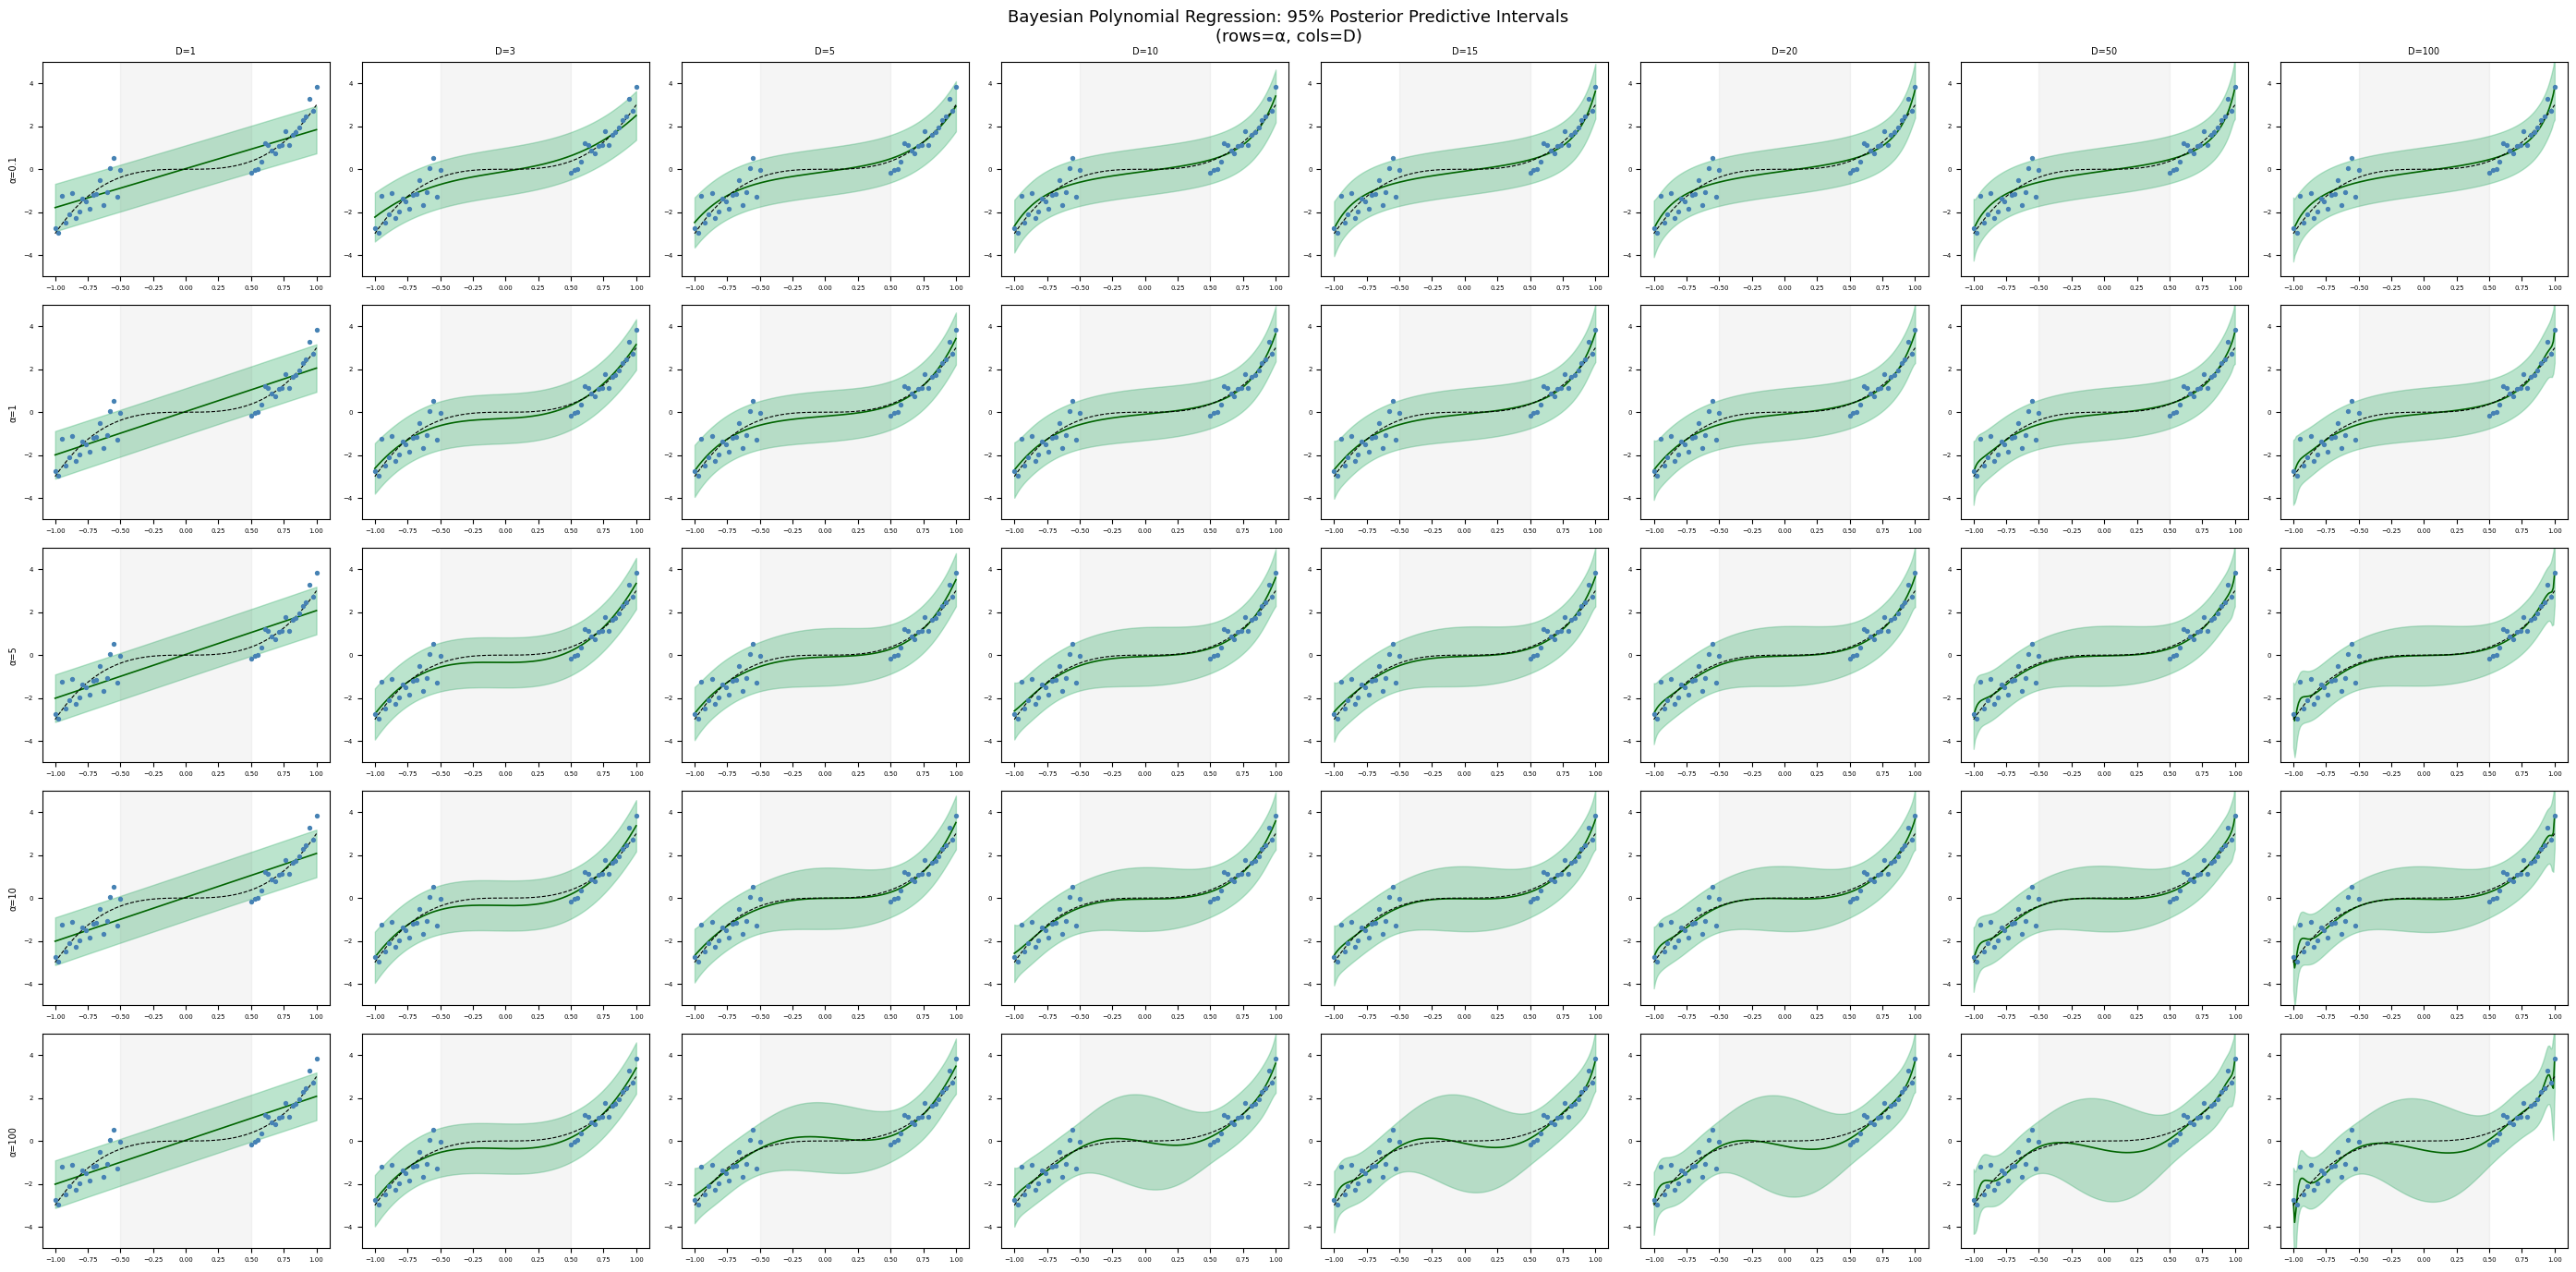

In [9]:
np.random.seed(5)
x_train, y_train, x_test = generate_data(number_of_points=20)
noise_var = 0.3

degrees = [1, 3, 5, 10, 15, 20, 50, 100]
alphas  = [0.1, 1, 5, 10, 100]

fig, axes = plt.subplots(len(alphas), len(degrees), figsize=(28, 14))

for row, alpha in enumerate(alphas):
    for col, D in enumerate(degrees):
        poly = PolynomialFeatures(degree=D, include_bias=True)
        Phi_tr = poly.fit_transform(x_train.reshape(-1, 1))
        Phi_te = poly.transform(x_test.reshape(-1, 1))

        # Posterior
        prior_prec = (1.0 / alpha) * np.eye(Phi_tr.shape[1])
        Sigma_N = np.linalg.inv(prior_prec + Phi_tr.T @ Phi_tr / noise_var)
        mu_N    = Sigma_N @ (Phi_tr.T @ y_train) / noise_var

        # Predictive mean and std
        pred_mean = Phi_te @ mu_N
        pred_var  = noise_var + np.sum(Phi_te @ Sigma_N * Phi_te, axis=1)
        pred_std  = np.sqrt(np.clip(pred_var, 0, None))

        ax = axes[row, col]
        ax.fill_between(x_test, pred_mean - 1.96*pred_std, pred_mean + 1.96*pred_std,
                        alpha=0.35, color='mediumseagreen', label='95% PI')
        ax.plot(x_test, pred_mean, color='darkgreen', lw=1.2)
        ax.plot(x_test, 3*x_test**3, 'k--', lw=0.8)
        ax.scatter(x_train, y_train, s=8, color='steelblue', zorder=5)
        ax.axvspan(-0.5, 0.5, alpha=0.08, color='grey')
        ax.set_ylim(-5, 5)
        if row == 0: ax.set_title(f'D={D}', fontsize=7)
        if col == 0: ax.set_ylabel(f'α={alpha}', fontsize=7)
        ax.tick_params(labelsize=5)

plt.suptitle('Bayesian Polynomial Regression: 95% Posterior Predictive Intervals\n(rows=α, cols=D)', fontsize=13)
plt.tight_layout()
plt.show()

**Discussion — Role of D and α**

- **D (degree)** controls the **flexibility** of the function class. Higher D allows more complex shapes but increases the risk of overfitting in the training region and introduces wilder extrapolation in the gap.

- **α (prior variance)** controls how tightly the weights are shrunk toward zero. Small α → strong regularization → narrow intervals everywhere, functions stay near zero in the gap. Large α → weak regularization → the posterior uncertainty in the gap grows (desirable!) as the posterior has not been constrained much by the prior, letting the data (or lack thereof) speak.

Crucially, unlike bootstrap ensembles, the Bayesian posterior predictive interval **remains wide in the gap even with large D and small α** because the model has seen no data there and the prior does not pin down the weights. This is the behaviour we want for safe deployment.

### Problem II.3 — Model Evaluation: Log-Likelihood (4 marks)

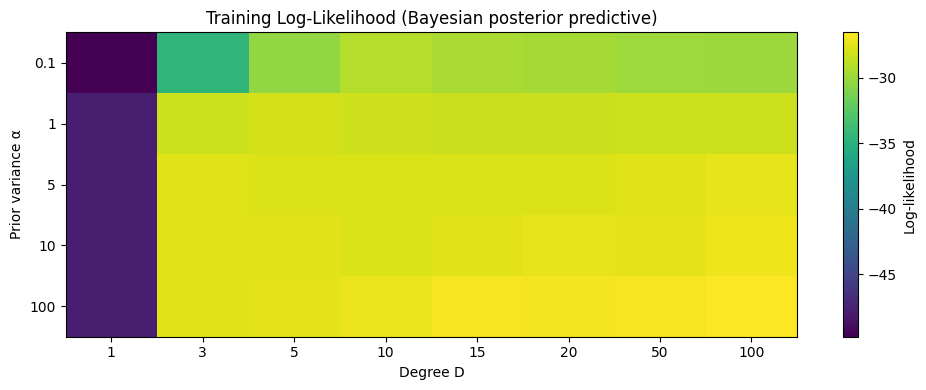

Best (α, D) by log-likelihood: α=100, D=100


In [10]:
np.random.seed(5)
x_train, y_train, x_test = generate_data(number_of_points=20)
noise_var = 0.3
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
alphas  = [0.1, 1, 5, 10, 100]

# Evaluate log-likelihood on training data
ll_grid = np.zeros((len(alphas), len(degrees)))

for row, alpha in enumerate(alphas):
    for col, D in enumerate(degrees):
        poly = PolynomialFeatures(degree=D, include_bias=True)
        Phi_tr = poly.fit_transform(x_train.reshape(-1, 1))

        prior_prec = (1.0 / alpha) * np.eye(Phi_tr.shape[1])
        Sigma_N = np.linalg.inv(prior_prec + Phi_tr.T @ Phi_tr / noise_var)
        mu_N    = Sigma_N @ (Phi_tr.T @ y_train) / noise_var

        # Predictive distribution on training points
        pred_mean = Phi_tr @ mu_N
        pred_var  = noise_var + np.sum(Phi_tr @ Sigma_N * Phi_tr, axis=1)

        # Log-likelihood sum
        ll = norm.logpdf(y_train, loc=pred_mean, scale=np.sqrt(pred_var)).sum()
        ll_grid[row, col] = ll

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(ll_grid, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(degrees)));  ax.set_xticklabels(degrees)
ax.set_yticks(range(len(alphas)));   ax.set_yticklabels(alphas)
ax.set_xlabel('Degree D');  ax.set_ylabel('Prior variance α')
ax.set_title('Training Log-Likelihood (Bayesian posterior predictive)')
plt.colorbar(im, ax=ax, label='Log-likelihood')
plt.tight_layout()
plt.show()

best_idx = np.unravel_index(np.argmax(ll_grid), ll_grid.shape)
print(f'Best (α, D) by log-likelihood: α={alphas[best_idx[0]]}, D={degrees[best_idx[1]]}')

**Discussion — Log-Likelihood and Predictive Uncertainty**

Higher log-likelihood on the training set indicates the predictive distribution assigns higher probability to the observed training targets. Models with large α (weak prior) and high D often achieve the highest training log-likelihood because they fit the training points closely with narrow predictive variance. **However, narrow training-set uncertainty does not imply useful uncertainty in the gap.** In fact, high-LL models frequently have overconfident and unreliable intervals in the covariate-shifted region.

**Measuring uncertainty in the context of covariate shift:** Neither MSE nor log-likelihood on training data (or even in-distribution test data) captures model quality *under covariate shift*. Good uncertainty should satisfy: (1) intervals cover the true function with high probability, and (2) intervals widen in regions far from training data. A useful metric would be **coverage probability in unseen regions** — but this requires ground-truth knowledge of which regions are unseen, which is rarely available in practice. This is precisely why conformal prediction and Bayesian uncertainty are active research areas.

### Problem II.4 — Bayesian vs. Frequentist (Bootstrap) Uncertainty (3 marks)

**Bootstrap (Frequentist) Uncertainty**

*Advantages:*
- Model-free: does not require specifying a prior, making it broadly applicable.
- Computationally straightforward for any model that can be retrained.
- Asymptotically valid: as n → ∞ the bootstrap distribution converges to the true sampling distribution of the estimator.

*Disadvantages:*
- Measures **sampling variability**, not epistemic uncertainty about the function. As shown in Problem 3, bootstrap intervals collapse in the gap when data is abundant, giving false confidence in covariate-shifted regions.
- Requires fitting B separate models, which is expensive for large models.
- Provides no principled way to incorporate domain knowledge.

*When to prefer bootstrap:* When you have abundant data and the test distribution closely resembles training (no covariate shift), and when the model is complex (e.g. neural network) where specifying a prior is difficult. For example, predicting hospital readmission in a well-studied population with large EHR datasets.

---

**Bayesian Posterior Predictive Uncertainty**

*Advantages:*
- Naturally expresses **epistemic uncertainty**: intervals remain wide in unseen regions, reflecting lack of information rather than sampling variability.
- Allows incorporation of domain expertise through the prior.
- Provides well-calibrated intervals under model assumptions even with small datasets.

*Disadvantages:*
- Requires specifying a prior, which may be wrong (misspecified model gives overconfident intervals).
- Closed-form posterior only available for conjugate models; general Bayesian inference is computationally expensive.
- Epistemic uncertainty still only covers uncertainty *within the model class*.

*When to prefer Bayesian:* When data is scarce and domain expertise can guide prior construction. For example, a clinical trial with n=30 patients, where a physician can specify a plausible range for treatment effects. The Bayesian model can encode that knowledge and produce principled uncertainty bounds even with limited data.

### Problem II.5 — Measuring Uncertainty (3 marks)

**Are MSE or log-likelihood appropriate for evaluating uncertainty under covariate shift?**

No. Both MSE and log-likelihood are computed on available data (training or in-distribution test data). They measure predictive accuracy where data exists, not uncertainty quality where data is absent. A model can achieve excellent MSE in the training region while completely failing in the gap, and neither metric would flag this.

**Do standard ML best-practices help or hamper useful uncertainty?**

They generally **hamper** useful uncertainty. Practices like regularization, early stopping, and cross-validated model selection all minimize in-distribution loss — they actively suppress the model's tendency to have wide, variable predictions in data-poor regions, which is precisely the behaviour we want. Similarly, ensembling with resampling reduces variance everywhere, including the covariate-shifted region.

**What would be a good metric for uncertainty?**

A principled definition of *good uncertainty* (without reference to a downstream task) is **coverage under distribution shift**: a predictive interval $[L(x), U(x)]$ at level $(1-\alpha)$ is good if $P(y \in [L(x), U(x)]) \geq 1 - \alpha$ for all $x$ in the deployment distribution, even when the deployment distribution differs from training. This leads naturally to conformal prediction (Part IV), which provides finite-sample coverage guarantees under mild exchangeability assumptions.

---
## Part III: Calibration and Posterior Predictive Checks (12 marks)

In [11]:
# Helper functions (provided, do not modify)
def reliability_diagram(probs, labels, n_bins=10, title='Reliability Diagram'):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers, frac_pos, counts = [], [], []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() > 0:
            bin_centers.append(probs[mask].mean())
            frac_pos.append(labels[mask].mean())
            counts.append(mask.sum())
    bin_centers, frac_pos = np.array(bin_centers), np.array(frac_pos)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot([0,1],[0,1],'k--', label='Perfect calibration')
    ax1.plot(bin_centers, frac_pos, 'o-', color='steelblue', label='Model')
    ax1.set_xlabel('Mean predicted probability'); ax1.set_ylabel('Fraction of positives')
    ax1.set_title(title); ax1.legend()
    ax2.bar(bin_centers, counts, width=0.07, color='steelblue', alpha=0.7)
    ax2.set_xlabel('Predicted probability'); ax2.set_ylabel('Count'); ax2.set_title('Confidence histogram')
    plt.tight_layout(); plt.show()
    return bin_centers, frac_pos, np.array(counts)

def ece_binary(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            acc = labels[mask].mean()
            conf = probs[mask].mean()
            ece += mask.sum() * abs(acc - conf)
    return ece / len(probs)

def brier_binary(probs, labels):
    return np.mean((probs - labels)**2)

def temperature_scale(logits, T):
    return 1 / (1 + np.exp(-logits / T))

--- Baseline Test Metrics ---
NLL:   0.4001
Brier: 0.1218
ECE:   0.0415


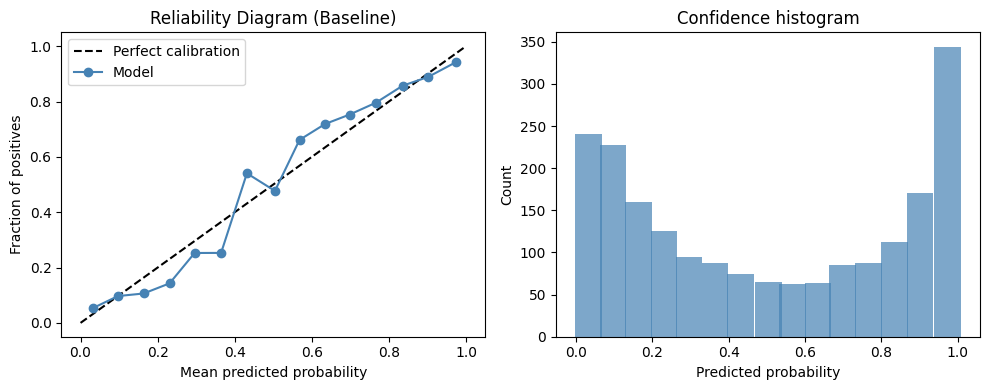

(array([0.03310935, 0.09705299, 0.16371101, 0.23092789, 0.29591047,
        0.36457898, 0.43155415, 0.50426484, 0.56802806, 0.63431001,
        0.69813301, 0.76585632, 0.83561018, 0.90178986, 0.97330717]),
 array([0.05416667, 0.0969163 , 0.10625   , 0.14285714, 0.25263158,
        0.25287356, 0.54054054, 0.47692308, 0.66129032, 0.71875   ,
        0.75294118, 0.79545455, 0.85714286, 0.88888889, 0.94186047]),
 array([240, 227, 160, 126,  95,  87,  74,  65,  62,  64,  85,  88, 112,
        171, 344]))

In [12]:
# Generate classification dataset
np.random.seed(42)
X, y = make_classification(n_samples=8000, n_features=20, n_informative=10,
                            n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Train logistic regression
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf.fit(X_train, y_train)
p_test = clf.predict_proba(X_test)[:, 1]

print('--- Baseline Test Metrics ---')
print(f'NLL:   {log_loss(y_test, p_test):.4f}')
print(f'Brier: {brier_binary(p_test, y_test):.4f}')
print(f'ECE:   {ece_binary(p_test, y_test, n_bins=15):.4f}')

reliability_diagram(p_test, y_test, n_bins=15, title='Reliability Diagram (Baseline)')

### Part III — Questions

**1. Is the model overconfident or underconfident?**

Examine the reliability diagram. If the model's curve lies **below** the diagonal (predicted probability > fraction positive), the model is **overconfident** — it assigns high probabilities to positive cases more often than warranted. If above the diagonal, the model is **underconfident**. Logistic regression trained with L2 regularization (sklearn default) tends to be slightly underconfident, as regularization shrinks probabilities toward 0.5.

**2. Which metrics directly measure calibration?**

- **ECE** directly measures calibration: it computes the weighted average gap between predicted probability and empirical accuracy across confidence bins. A perfectly calibrated model has ECE = 0.
- **NLL (log-loss)** is a proper scoring rule that jointly rewards both accuracy and calibration — a model can improve NLL either by being more accurate or better calibrated. It measures calibration indirectly.
- **Brier score** similarly rewards both discrimination and calibration; it is proper but not a pure calibration metric.

**ECE is the most direct** single measure of calibration; the others conflate calibration with discriminative performance.

**3. Relationship between regularization and uncertainty estimation**

L2 regularization shrinks logits toward zero, which pulls predicted probabilities toward 0.5. This tends to produce **underconfident** models (probability estimates are too moderate). Temperature scaling post-hoc corrects this by finding a scalar T that adjusts all logits. If T > 1, the model was overconfident (sharpening logits → flatter probabilities); if T < 1, it was underconfident.

Best Temperature T = 1.1911


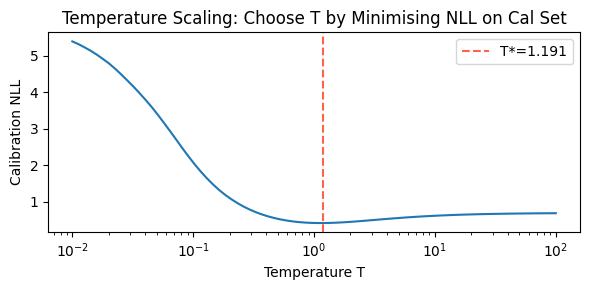


--- Test Metrics ---
Before: NLL=0.4021  Brier=0.1212  ECE=0.0485
After:  NLL=0.4026  Brier=0.1230  ECE=0.0497


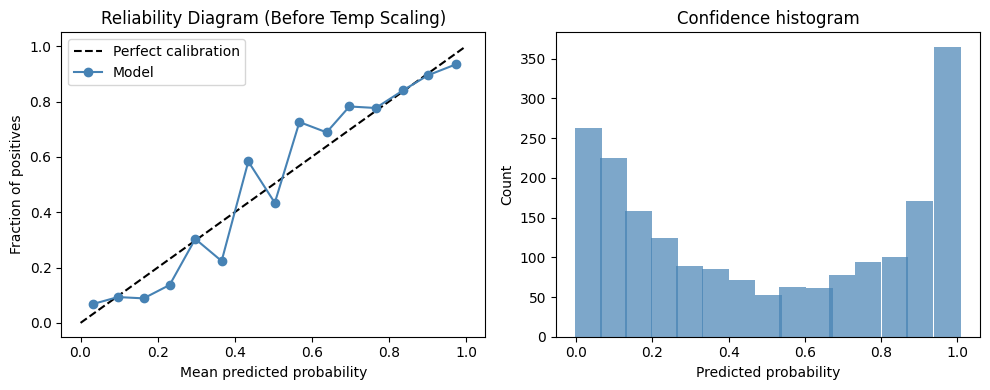

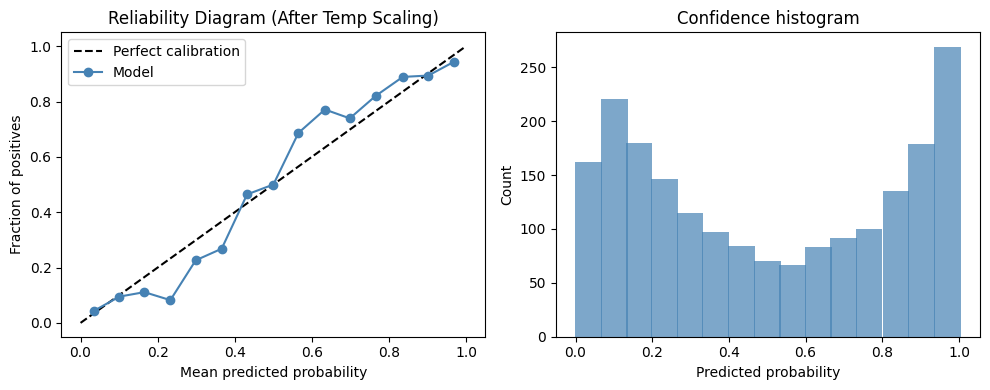

(array([0.0342234 , 0.10095002, 0.16563162, 0.23297869, 0.29871047,
        0.36609757, 0.43197538, 0.50022909, 0.56519977, 0.63389781,
        0.69841896, 0.76533087, 0.83586374, 0.90223658, 0.96952517]),
 array([0.04320988, 0.09502262, 0.11111111, 0.08219178, 0.22608696,
        0.26804124, 0.46428571, 0.5       , 0.68656716, 0.77108434,
        0.73913043, 0.82      , 0.88888889, 0.89385475, 0.94423792]),
 array([162, 221, 180, 146, 115,  97,  84,  70,  67,  83,  92, 100, 135,
        179, 269]))

In [13]:
# Temperature Scaling
X_tr, X_cal, y_tr, y_cal = train_test_split(X_train, y_train, test_size=0.3, random_state=1, stratify=y_train)

clf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf2.fit(X_tr, y_tr)

logits_cal  = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_cal))
logits_test = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_test))

Ts = np.logspace(-2, 2, 80)
cal_nll = [log_loss(y_cal, temperature_scale(logits_cal, T)) for T in Ts]
best_T = Ts[np.argmin(cal_nll)]
print(f'Best Temperature T = {best_T:.4f}')

plt.figure(figsize=(6, 3))
plt.plot(Ts, cal_nll)
plt.axvline(best_T, color='tomato', linestyle='--', label=f'T*={best_T:.3f}')
plt.xscale('log'); plt.xlabel('Temperature T'); plt.ylabel('Calibration NLL')
plt.title('Temperature Scaling: Choose T by Minimising NLL on Cal Set')
plt.legend(); plt.tight_layout(); plt.show()

p_before = 1 / (1 + np.exp(-logits_test))
p_after  = temperature_scale(logits_test, best_T)

print('\n--- Test Metrics ---')
print(f'Before: NLL={log_loss(y_test, p_before):.4f}  Brier={brier_binary(p_before, y_test):.4f}  ECE={ece_binary(p_before, y_test, n_bins=15):.4f}')
print(f'After:  NLL={log_loss(y_test, p_after):.4f}  Brier={brier_binary(p_after, y_test):.4f}  ECE={ece_binary(p_after, y_test, n_bins=15):.4f}')

reliability_diagram(p_before, y_test, n_bins=15, title='Reliability Diagram (Before Temp Scaling)')
reliability_diagram(p_after,  y_test, n_bins=15, title='Reliability Diagram (After Temp Scaling)')

### Posterior Predictive Checks (PPC) for Regression

In [14]:
np.random.seed(0)
Xr, yr = make_regression(n_samples=4000, n_features=10, noise=15.0, random_state=0)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=0)

reg = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
reg.fit(Xr_train, yr_train)

mu_train = reg.predict(Xr_train)
mu_test  = reg.predict(Xr_test)

resid    = yr_train - mu_train
sigma_hat = np.std(resid)
print(f'Estimated sigma: {sigma_hat:.4f}')

Estimated sigma: 14.7257


In [15]:
import math

def gaussian_nll(y, mu, sigma):
    """Average negative log likelihood for N(mu, sigma^2). Returns a scalar."""
    n = len(y)
    nll = 0.5 * np.log(2 * math.pi * sigma**2) + 0.5 * np.mean((y - mu)**2 / sigma**2)
    return nll

print('Test NLL:', gaussian_nll(yr_test, mu_test, sigma_hat))

Test NLL: 4.102061463732172


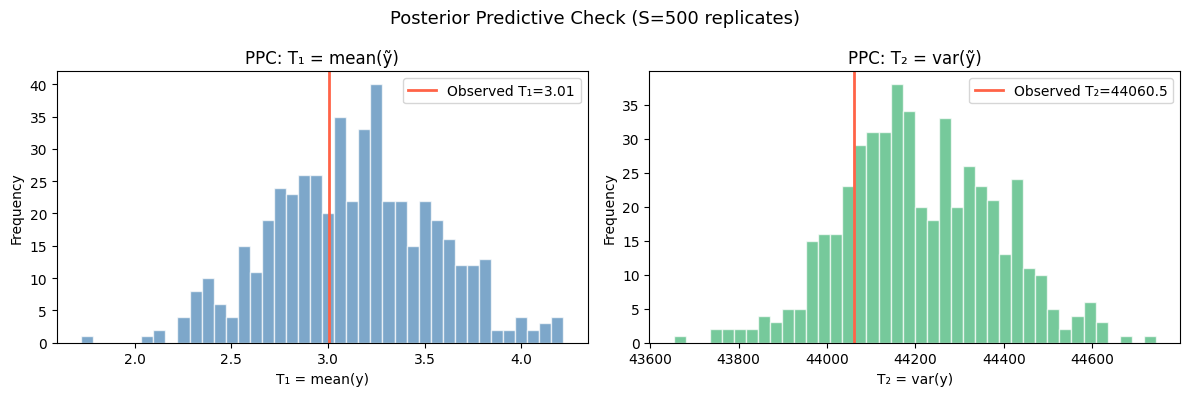

Bayesian p-value T₁: 0.762
Bayesian p-value T₂: 0.814


In [16]:
# PPC: simulate S=500 replicates and compare T1 = mean(y), T2 = var(y)
S = 500
n_test = len(yr_test)

T1_rep = np.zeros(S)
T2_rep = np.zeros(S)

for s in range(S):
    y_tilde = np.random.normal(mu_test, sigma_hat, size=n_test)
    T1_rep[s] = np.mean(y_tilde)
    T2_rep[s] = np.var(y_tilde)

T1_obs = np.mean(yr_test)
T2_obs = np.var(yr_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(T1_rep, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(T1_obs, color='tomato', lw=2, label=f'Observed T₁={T1_obs:.2f}')
axes[0].set_xlabel('T₁ = mean(y)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('PPC: T₁ = mean(ỹ)')
axes[0].legend()

axes[1].hist(T2_rep, bins=40, color='mediumseagreen', alpha=0.7, edgecolor='white')
axes[1].axvline(T2_obs, color='tomato', lw=2, label=f'Observed T₂={T2_obs:.1f}')
axes[1].set_xlabel('T₂ = var(y)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('PPC: T₂ = var(ỹ)')
axes[1].legend()

plt.suptitle('Posterior Predictive Check (S=500 replicates)', fontsize=13)
plt.tight_layout()
plt.show()

p_val_T1 = np.mean(np.abs(T1_rep - np.mean(T1_rep)) >= np.abs(T1_obs - np.mean(T1_rep)))
p_val_T2 = np.mean(T2_rep >= T2_obs)
print(f'Bayesian p-value T₁: {p_val_T1:.3f}')
print(f'Bayesian p-value T₂: {p_val_T2:.3f}')

**PPC Interpretation**

- **T₁ (mean):** If the observed mean falls well within the distribution of replicated means, the model captures the marginal location of the data well. A p-value near 0.5 suggests the model is well-calibrated for this statistic.

- **T₂ (variance):** This is the more diagnostic check. If the observed variance falls outside the distribution of replicated variances, the model is misspecified — either σ is too small (model underestimates spread) or the noise is not Gaussian. A p-value near 0 or 1 flags a problem.

Since σ was estimated from training residuals (which include both noise and any model misfit), and ridge regression tends to slightly underfit, the observed test variance may be slightly higher than the replicated variance, indicating mild underdispersion.

---
## Part IV: Conformal Prediction (12 marks)

In [17]:
# Data splits: 60% train, 20% calibration, 20% test
np.random.seed(0)
Xr_tr, Xr_temp, yr_tr, yr_temp = train_test_split(Xr, yr, test_size=0.4, random_state=0)
Xr_cal, Xr_te, yr_cal, yr_te = train_test_split(Xr_temp, yr_temp, test_size=0.5, random_state=0)

print(f'Train: {len(yr_tr)}, Calibration: {len(yr_cal)}, Test: {len(yr_te)}')

base = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
base.fit(Xr_tr, yr_tr)

pred_cal = base.predict(Xr_cal)
pred_te  = base.predict(Xr_te)

resid_cal = np.abs(yr_cal - pred_cal)


def split_conformal_interval(pred, resid_cal, alpha=0.1):
    """
    Compute split conformal prediction intervals.

    Parameters
    ----------
    pred      : array of shape (n_test,) — point predictions
    resid_cal : array of shape (n_cal,)  — |y_i - yhat_i| on calibration set
    alpha     : miscoverage level (target coverage = 1 - alpha)

    Returns
    -------
    lower, upper : arrays of shape (n_test,)
    """
    n_cal = len(resid_cal)
    # Finite-sample corrected quantile: ceil((n_cal+1)*(1-alpha)) / n_cal
    level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
    level = min(level, 1.0)  # clip to 1 if alpha is very small
    q = np.quantile(resid_cal, level)
    lower = pred - q
    upper = pred + q
    return lower, upper


# Quick sanity check
L, U = split_conformal_interval(pred_te, resid_cal, alpha=0.1)
coverage = np.mean((yr_te >= L) & (yr_te <= U))
avg_width = np.mean(U - L)
print(f'α=0.10  Empirical coverage: {coverage:.4f}  Average interval width: {avg_width:.4f}')

Train: 2400, Calibration: 800, Test: 800
α=0.10  Empirical coverage: 0.8988  Average interval width: 47.0328


### Problem IV.1 — Coverage and Width for α ∈ {0.05, 0.10, 0.20}

     α   Target coverage  Empirical coverage     Avg width
------------------------------------------------------------
  0.05              0.95              0.9575       57.3899
  0.10              0.90              0.8988       47.0328
  0.20              0.80              0.8100       37.8548


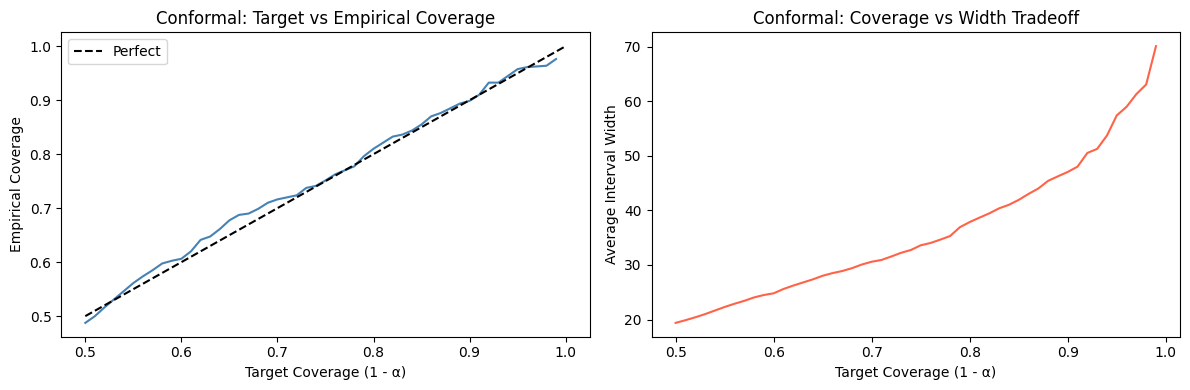

In [18]:
alphas_cp = [0.05, 0.10, 0.20]

print(f'{"α":>6}  {"Target coverage":>16}  {"Empirical coverage":>18}  {"Avg width":>12}')
print('-' * 60)

results = []
for alpha in alphas_cp:
    L, U = split_conformal_interval(pred_te, resid_cal, alpha=alpha)
    cov   = np.mean((yr_te >= L) & (yr_te <= U))
    width = np.mean(U - L)
    results.append((alpha, cov, width))
    print(f'{alpha:>6.2f}  {1-alpha:>16.2f}  {cov:>18.4f}  {width:>12.4f}')

# Visualise coverage vs width tradeoff
alphas_fine = np.linspace(0.01, 0.5, 50)
covs, widths = [], []
for a in alphas_fine:
    L, U = split_conformal_interval(pred_te, resid_cal, alpha=a)
    covs.append(np.mean((yr_te >= L) & (yr_te <= U)))
    widths.append(np.mean(U - L))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(1 - alphas_fine, covs, color='steelblue')
axes[0].plot([0.5, 1], [0.5, 1], 'k--', label='Perfect')
axes[0].set_xlabel('Target Coverage (1 - α)'); axes[0].set_ylabel('Empirical Coverage')
axes[0].set_title('Conformal: Target vs Empirical Coverage'); axes[0].legend()

axes[1].plot(1 - alphas_fine, widths, color='tomato')
axes[1].set_xlabel('Target Coverage (1 - α)'); axes[1].set_ylabel('Average Interval Width')
axes[1].set_title('Conformal: Coverage vs Width Tradeoff')

plt.tight_layout()
plt.show()

**Interpretation of Coverage–Width Tradeoff**

The results demonstrate the fundamental tradeoff in conformal prediction:

- **Higher target coverage** (smaller α) requires a larger quantile q of the calibration residuals, producing **wider intervals**. This ensures that a larger fraction of test points fall inside the interval.
- **Lower target coverage** (larger α) uses a smaller quantile q, yielding **narrower, more informative intervals** at the cost of more test points falling outside.

Crucially, the empirical coverage closely tracks the target coverage (1 − α), validating the theoretical guarantee. The choice of α should be driven by the downstream risk tolerance: in safety-critical settings (e.g. drug dosing), one would choose α = 0.01 or lower, accepting wide intervals to nearly guarantee coverage.

### Problem IV.2 — Coverage Guarantees, Covariate Shift, and Weighted Conformal Methods

**Under what assumptions does split conformal guarantee coverage?**

Split conformal prediction guarantees **marginal coverage** — $P(y_{n+1} \in [L(x_{n+1}), U(x_{n+1})]) \geq 1 - \alpha$ — under the assumption that the calibration and test observations are **exchangeable**. The most common sufficient condition for exchangeability is that the calibration and test data are i.i.d. from the same distribution. The guarantee is finite-sample (holds for any n) and distribution-free (no parametric assumptions on the data-generating process).

**Why might these assumptions fail under covariate shift?**

Covariate shift means the test inputs $x_{test}$ are drawn from a different distribution than the calibration inputs $x_{cal}$, even though the conditional $p(y|x)$ remains the same. This directly violates exchangeability: calibration and test points are no longer identically distributed. As a result, the quantile q computed on calibration residuals may be too small for the test distribution (e.g. if test points fall in a region where the base model is less accurate), leading to **undercoverage** on the test set. For example, in the polynomial regression setting, calibration residuals from x ∈ [-1, -0.5] ∪ [0.5, 1] would underestimate residuals in the gap x ∈ [-0.5, 0.5], causing the conformal interval to be too narrow there.

**High-level idea behind weighted conformal methods**

Weighted conformal methods (e.g. Tibshirani et al., 2019) restore validity under covariate shift by re-weighting the calibration residuals according to the **likelihood ratio** $w(x) = p_{test}(x) / p_{train}(x)$. Intuitively, calibration points that are more representative of the test distribution receive higher weight, so the effective quantile is computed over a weighted empirical distribution that approximates what the residuals would look like if calibration data had come from the test distribution. This recovers marginal coverage under covariate shift, provided the likelihood ratios can be estimated (e.g. via density ratio estimation or a domain classifier).